# Global EV Transition Readiness Index 2024

## Import Libraries

In [110]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Load Datasets

The project uses EV data from the IEA, population and national context data from the World Bank, low-carbon electricity data from OWID, and scraped renewable electricity data from CountryEconomy.

In [111]:
df_iea = pd.read_excel(r"Datasets\EVDataExplorer2025.xlsx", sheet_name="GEVO_EV_2025")
df_population = pd.read_csv(r"Datasets\API_SP\API_SP.POP.TOTL_DS2_en_csv_v2_58.csv", skiprows=4)
df_gdp = pd.read_csv(r"Datasets\API_NY\API_NY.GDP.PCAP.PP.KD_DS2_en_csv_v2_1700.csv", skiprows=4)
df_electricity = pd.read_csv(r"Datasets\API_EG\API_EG.USE.ELEC.KH.PC_DS2_en_csv_v2_1655.csv", skiprows=4)
df_owid = pd.read_csv(r"Datasets\owid_share_electricity_low_carbon_full.csv")
df_renewable = pd.read_csv(r"Datasets\countryeconomy_renewable_electricity_2024.csv")

## Preview Source Data

In [112]:
df_iea.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
0,World,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,170000000.0,_World
1,World,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,150000000.0,_World
2,China,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,91000000.0,Other
3,China,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,82000000.0,Other
4,World,Projection-STEPS,EV stock,Cars,PHEV,2030,Vehicles,82000000.0,_World


In [113]:
df_population.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,NaN,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,NaN,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN,NaN


In [114]:
df_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,38116.831099,39278.829727,39652.632070,30347.637185,35104.786804,38979.835825,41964.771191,44558.928759,NaN,NaN
1,Africa Eastern and Southern,AFE,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,4214.397085,4220.912502,4195.865418,3978.931395,4056.113017,4106.501907,4083.993003,4106.434140,NaN,NaN
2,Afghanistan,AFG,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,2952.998916,2902.392113,2927.245144,2769.685745,2144.166570,1981.710168,1983.812620,NaN,NaN,NaN
3,Africa Western and Central,AFW,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,5999.744780,6016.312217,6059.606024,5687.849988,5690.967743,5806.172890,5874.951080,5996.395736,NaN,NaN
4,Angola,AGO,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,10414.235884,10000.944377,9648.011038,8960.337972,8862.281333,8950.142593,8788.261064,8901.887366,NaN,NaN


In [115]:
df_electricity.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Electric power consumption (kWh per capita),EG.USE.ELEC.KH.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Electric power consumption (kWh per capita),EG.USE.ELEC.KH.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,566.130764,568.138013,550.050979,513.707046,513.465287,502.713913,484.004412,NaN,NaN,NaN
2,Afghanistan,AFG,Electric power consumption (kWh per capita),EG.USE.ELEC.KH.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Electric power consumption (kWh per capita),EG.USE.ELEC.KH.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,179.985487,181.957492,187.406789,194.981500,201.929224,199.854471,207.456239,NaN,NaN,NaN
4,Angola,AGO,Electric power consumption (kWh per capita),EG.USE.ELEC.KH.PC,NaN,NaN,NaN,NaN,NaN,NaN,...,315.199297,370.736573,411.266103,439.118174,394.730414,373.031828,379.103010,NaN,NaN,NaN


In [116]:
df_owid.head()

,Entity,Code,Year,Share of electricity from low-carbon sources
0,ASEAN (Ember),NaN,2000,19.334143
1,ASEAN (Ember),NaN,2001,19.055025
2,ASEAN (Ember),NaN,2002,17.666613
3,ASEAN (Ember),NaN,2003,16.668121
4,ASEAN (Ember),NaN,2004,15.696422


In [117]:
df_renewable.head()

,country,year,installed_capacity_mw,generation_gwh,renewable_installed_capacity_mw,renewable_installed_capacity_share_pct,renewable_generation_gwh,renewable_generation_share_pct,renewable_generation_change_pct_points,source_url
0,United States,2024,1283644,4392552,451219,35.151413,1068551,24.33,1.34,https://countryeconomy.com/energy-and-environm...
1,United Kingdom,2024,114640,267980,57947,50.546930,140765,52.53,2.24,https://countryeconomy.com/energy-and-environm...
2,Germany,2024,287372,490177,177923,61.913826,279331,56.99,2.48,https://countryeconomy.com/energy-and-environm...
3,France,2024,160877,537227,70084,43.563716,150862,28.08,-0.08,https://countryeconomy.com/energy-and-environm...
4,Japan,2024,353288,907015,126313,35.753550,227883,25.12,-0.41,https://countryeconomy.com/energy-and-environm...


## Check Dataset Size and Structure

In [118]:
# Print the size of each dataset 
print("IEA EV data:", df_iea.shape)
print("Population data:", df_population.shape)
print("GDP data:", df_gdp.shape)
print("Electricity consumption data:", df_electricity.shape)
print("OWID low-carbon electricity data:", df_owid.shape)
print("Scraped renewable electricity data:", df_renewable.shape)

IEA EV data: (16436, 9)
Population data: (266, 71)
GDP data: (266, 71)
Electricity consumption data: (266, 71)
OWID low-carbon electricity data: (7872, 4)
Scraped renewable electricity data: (188, 10)


In [119]:
df_iea.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16436 entries, 0 to 16435
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region_country   16436 non-null  object 
 1   category         16436 non-null  object 
 2   parameter        16436 non-null  object 
 3   mode             16436 non-null  object 
 4   powertrain       16436 non-null  object 
 5   year             16436 non-null  int64  
 6   unit             16436 non-null  object 
 7   value            16436 non-null  float64
 8   Aggregate group  16436 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 1.1+ MB


In [120]:
df_population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            264 non-null    float64
 5   1961            264 non-null    float64
 6   1962            264 non-null    float64
 7   1963            264 non-null    float64
 8   1964            264 non-null    float64
 9   1965            264 non-null    float64
 10  1966            264 non-null    float64
 11  1967            264 non-null    float64
 12  1968            264 non-null    float64
 13  1969            264 non-null    float64
 14  1970            264 non-null    float64
 15  1971            264 non-null    float64
 16  1972            264 non-null    float64
 17  1973            264 non-null    flo

In [121]:
df_gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      flo

In [122]:
df_electricity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      flo

In [123]:
df_owid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7872 entries, 0 to 7871
Data columns (total 4 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Entity                                        7872 non-null   object 
 1   Code                                          7030 non-null   object 
 2   Year                                          7872 non-null   int64  
 3   Share of electricity from low-carbon sources  7872 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 246.1+ KB


In [124]:
df_renewable.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 10 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   country                                 188 non-null    object 
 1   year                                    188 non-null    int64  
 2   installed_capacity_mw                   188 non-null    int64  
 3   generation_gwh                          188 non-null    int64  
 4   renewable_installed_capacity_mw         188 non-null    int64  
 5   renewable_installed_capacity_share_pct  188 non-null    float64
 6   renewable_generation_gwh                188 non-null    int64  
 7   renewable_generation_share_pct          187 non-null    float64
 8   renewable_generation_change_pct_points  187 non-null    float64
 9   source_url                              188 non-null    object 
dtypes: float64(3), int64(5), object(2)
memory usage: 14.8+ KB


## Clean IEA EV Data

The IEA workbook contains different years, vehicle modes, powertrains, and both historical and projected values. Only historical 2024 country data is selected for the index.

In [125]:
# Keep the 2024 historical EV records needed for the index.
df_iea_2024 = df_iea[df_iea["year"] == 2024].copy()
df_iea_2024 = df_iea_2024[df_iea_2024["category"] == "Historical"]

# Car adoption indicators and public charger indicators are selected separately.
df_iea_2024 = df_iea_2024[
    ((df_iea_2024["parameter"].isin(["EV sales share", "EV stock share"])) &
     (df_iea_2024["mode"] == "Cars") &
     (df_iea_2024["powertrain"] == "EV")) |
    ((df_iea_2024["parameter"] == "EV stock") &
     (df_iea_2024["mode"] == "Cars") &
     (df_iea_2024["powertrain"].isin(["BEV", "PHEV", "FCEV"]))) |
    ((df_iea_2024["parameter"] == "EV charging points") &
     (df_iea_2024["mode"] == "EV") &
     (df_iea_2024["powertrain"].isin(["Publicly available slow", "Publicly available fast"])))
]

df_iea_2024.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
27,World,Historical,EV stock,Cars,BEV,2024,Vehicles,39000000.0,_World
43,Asia Pacific,Historical,EV stock,Cars,BEV,2024,Vehicles,24000000.0,Aggregate_sales_stock
44,China,Historical,EV stock,Cars,BEV,2024,Vehicles,23000000.0,Other
49,World,Historical,EV stock,Cars,PHEV,2024,Vehicles,19000000.0,_World
72,Asia Pacific,Historical,EV stock,Cars,PHEV,2024,Vehicles,11000000.0,Aggregate_sales_stock


In [126]:
# Check that the selected IEA indicators are the ones needed.
df_iea_2024[["parameter", "mode", "powertrain"]].value_counts()

parameter           mode  powertrain             
EV sales share      Cars  EV                         61
EV stock            Cars  PHEV                       48
                          BEV                        48
EV stock share      Cars  EV                         48
EV charging points  EV    Publicly available fast    43
                          Publicly available slow    43
EV stock            Cars  FCEV                       35
Name: count, dtype: int64

In [127]:
# EV sales share for cars
df_sales_share = df_iea_2024[
    (df_iea_2024["parameter"] == "EV sales share") &
    (df_iea_2024["mode"] == "Cars")
][["region_country", "value"]].copy()
df_sales_share = df_sales_share.rename(columns={"value": "EV_sales_share"})

# EV stock share for cars
df_stock_share = df_iea_2024[
    (df_iea_2024["parameter"] == "EV stock share") &
    (df_iea_2024["mode"] == "Cars")
][["region_country", "value"]].copy()
df_stock_share = df_stock_share.rename(columns={"value": "EV_stock_share"})

# EV stock is split by powertrain, so BEV, PHEV, and FCEV are summed.
df_stock = df_iea_2024[
    (df_iea_2024["parameter"] == "EV stock") &
    (df_iea_2024["mode"] == "Cars")
].groupby("region_country", as_index=False)["value"].sum()
df_stock = df_stock.rename(columns={"value": "EV_stock"})

# Public slow charging points
df_slow = df_iea_2024[
    (df_iea_2024["parameter"] == "EV charging points") &
    (df_iea_2024["powertrain"] == "Publicly available slow")
][["region_country", "value"]].copy()
df_slow = df_slow.rename(columns={"value": "Public_slow_chargers"})

# Public fast charging points
df_fast = df_iea_2024[
    (df_iea_2024["parameter"] == "EV charging points") &
    (df_iea_2024["powertrain"] == "Publicly available fast")
][["region_country", "value"]].copy()
df_fast = df_fast.rename(columns={"value": "Public_fast_chargers"})

In [128]:
# Merge the selected IEA indicators into one country-level EV table.
df_iea_clean = df_sales_share.copy()
df_iea_clean = pd.merge(df_iea_clean, df_stock_share, on="region_country", how="outer")
df_iea_clean = pd.merge(df_iea_clean, df_stock, on="region_country", how="outer")
df_iea_clean = pd.merge(df_iea_clean, df_slow, on="region_country", how="outer")
df_iea_clean = pd.merge(df_iea_clean, df_fast, on="region_country", how="outer")

df_iea_clean = df_iea_clean.rename(columns={"region_country": "Country"})

df_iea_clean.head()

,Country,EV_sales_share,EV_stock_share,EV_stock,Public_slow_chargers,Public_fast_chargers
0,Africa,0.62,0.054,19203.0,NaN,NaN
1,Asia Pacific,31.00,6.700,35045000.0,NaN,NaN
2,Australia,13.00,1.900,302089.0,2800.0,3900.0
3,Austria,24.00,5.300,275062.0,21000.0,6300.0
4,Belgium,43.00,11.000,670100.0,72000.0,2600.0


## Inspect IEA Country and Region Values

Before removing non-country rows, the unique values from the IEA country field are printed. This shows which entries are actual countries and which entries are regional aggregates.

In [129]:
print("Unique IEA country and region values before filtering:")

for country in sorted(df_iea_clean["Country"].dropna().unique()):
    print(country)

print("\nTotal unique IEA values before filtering:", df_iea_clean["Country"].nunique())

Unique IEA country and region values before filtering:
Africa
Asia Pacific
Australia
Austria
Belgium
Brazil
Bulgaria
Canada
Central and South America
Chile
China
Colombia
Costa Rica
Croatia
Cyprus
Czech Republic
Denmark
EU27
Estonia
Europe
Finland
France
Germany
Greece
Hungary
Iceland
India
Indonesia
Ireland
Israel
Italy
Japan
Jordan
Korea
Latvia
Lithuania
Luxembourg
Malaysia
Mexico
Middle East and Caspian
Netherlands
New Zealand
North America
Norway
Poland
Portugal
Rest of the world
Romania
Russia
Slovakia
Slovenia
South Africa
Spain
Sweden
Switzerland
Thailand
Turkiye
USA
United Kingdom
Uzbekistan
Viet Nam
World

Total unique IEA values before filtering: 62


## Remove Non-Country Rows from IEA Data

The IEA file includes aggregate regions such as World and Europe. These are removed because the final index compares countries.

In [130]:
aggregate_rows = [
    "World", "Europe", "European Union", "Asia Pacific", "Rest of the world",
    "Other Europe", "Other Asia", "Central and South America",
    "Middle East", "Africa", "North America"
]

df_iea_clean = df_iea_clean[~df_iea_clean["Country"].isin(aggregate_rows)].copy()

print("Countries after removing aggregates:", df_iea_clean.shape[0])
df_iea_clean.head()

Countries after removing aggregates: 55


,Country,EV_sales_share,EV_stock_share,EV_stock,Public_slow_chargers,Public_fast_chargers
2,Australia,13.0,1.9,302089.0,2800.0,3900.0
3,Austria,24.0,5.3,275062.0,21000.0,6300.0
4,Belgium,43.0,11.0,670100.0,72000.0,2600.0
5,Brazil,6.4,0.7,214003.0,12000.0,600.0
6,Bulgaria,5.0,NaN,NaN,NaN,NaN


## Clean World Bank Data

The index uses 2024 as the main year. For supporting World Bank indicators, the closest available previous year is used where 2024 is missing. This follows the same logic as using the most recent available value to avoid unnecessary country loss.

In [131]:
# Use the closest available year up to 2024 for World Bank indicators.
def get_closest_world_bank_value(data, indicator_name, target_year=2024):
    year_columns = [column for column in data.columns if column.isdigit()]
    year_columns = [column for column in year_columns if int(column) <= target_year]
    year_columns = sorted(year_columns, reverse=True)
    
    rows = []
    
    for index, row in data.iterrows():
        selected_value = np.nan
        selected_year = np.nan
        
        for year in year_columns:
            if pd.notnull(row[year]):
                selected_value = row[year]
                selected_year = int(year)
                break
        
        rows.append({
            "Country": row["Country Name"],
            "Country_code": row["Country Code"],
            indicator_name: selected_value,
            indicator_name + "_year": selected_year
        })
    
    return pd.DataFrame(rows)

In [132]:
# Create the cleaned population table.
df_population_clean = get_closest_world_bank_value(df_population, "Population", 2024)
df_population_clean.head()

,Country,Country_code,Population,Population_year
0,Aruba,ABW,107995.0,2024.0
1,Africa Eastern and Southern,AFE,769280888.0,2024.0
2,Afghanistan,AFG,42647492.0,2024.0
3,Africa Western and Central,AFW,521764076.0,2024.0
4,Angola,AGO,37885849.0,2024.0


In [133]:
# Create the cleaned GDP per capita table.
df_gdp_clean = get_closest_world_bank_value(df_gdp, "GDP_per_capita_PPP", 2024)
df_gdp_clean.head()

,Country,Country_code,GDP_per_capita_PPP,GDP_per_capita_PPP_year
0,Aruba,ABW,44558.928759,2024.0
1,Africa Eastern and Southern,AFE,4106.434140,2024.0
2,Afghanistan,AFG,1983.812620,2023.0
3,Africa Western and Central,AFW,5996.395736,2024.0
4,Angola,AGO,8901.887366,2024.0


In [134]:
# Create the cleaned electric power consumption table.
df_electricity_clean = get_closest_world_bank_value(df_electricity, "Electric_power_consumption", 2024)
df_electricity_clean.head()

,Country,Country_code,Electric_power_consumption,Electric_power_consumption_year
0,Aruba,ABW,NaN,NaN
1,Africa Eastern and Southern,AFE,484.004412,2023.0
2,Afghanistan,AFG,NaN,NaN
3,Africa Western and Central,AFW,207.456239,2023.0
4,Angola,AGO,379.103010,2023.0


## Clean Electricity Sustainability Data

OWID low-carbon electricity share also uses 2024 as the main year. If a country does not have a 2024 value, the closest previous available year is used. The scraped renewable electricity dataset already contains 2024 values.

In [135]:
# Keep the latest OWID low-carbon electricity value available up to 2024.
df_owid_country = df_owid[df_owid["Code"].notna()].copy()
df_owid_country = df_owid_country[df_owid_country["Year"] <= 2024]

df_owid_country = df_owid_country.sort_values(["Entity", "Year"], ascending=[True, False])
df_owid_clean = df_owid_country.drop_duplicates("Entity")

df_owid_clean = df_owid_clean.rename(columns={
    "Entity": "Country",
    "Code": "Country_code",
    "Year": "Low_carbon_electricity_share_year",
    "Share of electricity from low-carbon sources": "Low_carbon_electricity_share"
})

df_owid_clean = df_owid_clean[["Country", "Country_code", "Low_carbon_electricity_share", "Low_carbon_electricity_share_year"]]

df_owid_clean.head()

,Country,Country_code,Low_carbon_electricity_share,Low_carbon_electricity_share_year
50,Afghanistan,AFG,86.868690,2024
90,Africa,OWID_AFR,25.546648,2024
181,Albania,ALB,100.000000,2024
221,Algeria,DZA,1.068908,2024
246,American Samoa,ASM,5.555555,2024


In [136]:
# Keep the renewable electricity columns needed from the scraped dataset.
df_renewable_clean = df_renewable[[
    "country",
    "year",
    "renewable_installed_capacity_share_pct",
    "renewable_generation_share_pct"
]].copy()

df_renewable_clean = df_renewable_clean.rename(columns={
    "country": "Country",
    "year": "Year",
    "renewable_installed_capacity_share_pct": "Renewable_installed_capacity_share",
    "renewable_generation_share_pct": "Renewable_generation_share"
})

df_renewable_clean.head()

,Country,Year,Renewable_installed_capacity_share,Renewable_generation_share
0,United States,2024,35.151413,24.33
1,United Kingdom,2024,50.546930,52.53
2,Germany,2024,61.913826,56.99
3,France,2024,43.563716,28.08
4,Japan,2024,35.753550,25.12


## Standardise Country Names

Some sources use different names for the same country. A common country key is created before merging.

In [137]:
# Standardise country names that appear differently across datasets.
country_name_changes = {
    "USA": "United States",
    "United States of America": "United States",
    "US": "United States",
    "UK": "United Kingdom",
    "Korea": "South Korea",
    "Korea, Rep.": "South Korea",
    "Republic of Korea": "South Korea",
    "Russian Federation": "Russia",
    "Turkiye": "Turkey",
    "TÃ¼rkiye": "Turkey",
    "Czechia": "Czech Republic",
    "Slovak Republic": "Slovakia",
    "Egypt, Arab Rep.": "Egypt",
    "Iran, Islamic Rep.": "Iran",
    "Viet Nam": "Vietnam"
}

df_iea_clean["Country"] = df_iea_clean["Country"].replace(country_name_changes)
df_population_clean["Country"] = df_population_clean["Country"].replace(country_name_changes)
df_gdp_clean["Country"] = df_gdp_clean["Country"].replace(country_name_changes)
df_electricity_clean["Country"] = df_electricity_clean["Country"].replace(country_name_changes)
df_owid_clean["Country"] = df_owid_clean["Country"].replace(country_name_changes)
df_renewable_clean["Country"] = df_renewable_clean["Country"].replace(country_name_changes)

In [138]:
# Create simple matching keys before merging the datasets.
df_iea_clean["Country_key"] = df_iea_clean["Country"].str.lower().str.strip()
df_population_clean["Country_key"] = df_population_clean["Country"].str.lower().str.strip()
df_gdp_clean["Country_key"] = df_gdp_clean["Country"].str.lower().str.strip()
df_electricity_clean["Country_key"] = df_electricity_clean["Country"].str.lower().str.strip()
df_owid_clean["Country_key"] = df_owid_clean["Country"].str.lower().str.strip()
df_renewable_clean["Country_key"] = df_renewable_clean["Country"].str.lower().str.strip()

## Validate Year Fallback Data

After selecting 2024 or the closest previous available year, the year used for each supporting indicator is checked. This makes the fallback process transparent.

In [139]:
# Print the years used so the fallback-year method is transparent.
print("Population year counts:")
print(df_population_clean["Population_year"].value_counts(dropna=False).sort_index())

print("\nGDP per capita PPP year counts:")
print(df_gdp_clean["GDP_per_capita_PPP_year"].value_counts(dropna=False).sort_index())

print("\nElectric power consumption year counts:")
print(df_electricity_clean["Electric_power_consumption_year"].value_counts(dropna=False).sort_index())

print("\nLow-carbon electricity share year counts:")
print(df_owid_clean["Low_carbon_electricity_share_year"].value_counts(dropna=False).sort_index())

Population year counts:
Population_year
2024.0    265
NaN         1
Name: count, dtype: int64

GDP per capita PPP year counts:
GDP_per_capita_PPP_year
2022.0      2
2023.0      9
2024.0    236
NaN        19
Name: count, dtype: int64

Electric power consumption year counts:
Electric_power_consumption_year
2014.0      1
2022.0      1
2023.0    141
2024.0     51
NaN        72
Name: count, dtype: int64

Low-carbon electricity share year counts:
Low_carbon_electricity_share_year
2009      1
2022      2
2023     15
2024    208
Name: count, dtype: int64


## Merge Cleaned Datasets

The IEA EV dataset is used as the base because the index is focused on EV transition readiness.

In [ ]:
# Merge all cleaned datasets into one country-level table.
merged_df = df_iea_clean.copy()

merged_df = pd.merge(merged_df, df_population_clean[["Country_key", "Population"]], on="Country_key", how="left")
merged_df = pd.merge(merged_df, df_gdp_clean[["Country_key", "GDP_per_capita_PPP"]], on="Country_key", how="left")
merged_df = pd.merge(merged_df, df_electricity_clean[["Country_key", "Electric_power_consumption"]], on="Country_key", how="left")
merged_df = pd.merge(merged_df, df_owid_clean[["Country_key", "Low_carbon_electricity_share"]], on="Country_key", how="left")
merged_df = pd.merge(merged_df, df_renewable_clean[["Country_key", "Renewable_installed_capacity_share", "Renewable_generation_share"]], on="Country_key", how="left")

print("Merged DataFrame shape:", merged_df.shape)
merged_df.head()

## Create Derived Indicators

Per-capita and per-EV indicators make countries more comparable.

In [141]:
# Create fair comparison indicators using population and EV stock.
merged_df["Total_public_chargers"] = merged_df["Public_slow_chargers"] + merged_df["Public_fast_chargers"]
merged_df["EV_stock_per_1000_people"] = merged_df["EV_stock"] / merged_df["Population"] * 1000
merged_df["Total_public_chargers_per_1000_EVs"] = merged_df["Total_public_chargers"] / merged_df["EV_stock"] * 1000
merged_df["Slow_chargers_per_100000_people"] = merged_df["Public_slow_chargers"] / merged_df["Population"] * 100000
merged_df["Fast_chargers_per_100000_people"] = merged_df["Public_fast_chargers"] / merged_df["Population"] * 100000

merged_df.head()

,Country,EV_sales_share,EV_stock_share,EV_stock,Public_slow_chargers,Public_fast_chargers,Country_key,Population,Population_year,GDP_per_capita_PPP,...,Electric_power_consumption_year,Low_carbon_electricity_share,Low_carbon_electricity_share_year,Renewable_installed_capacity_share,Renewable_generation_share,Total_public_chargers,EV_stock_per_1000_people,Total_public_chargers_per_1000_EVs,Slow_chargers_per_100000_people,Fast_chargers_per_100000_people
0,Australia,13.0,1.9,302089.0,2800.0,3900.0,australia,27196812.0,2024.0,60303.981712,...,2024.0,35.076690,2024.0,52.107585,38.10,6700.0,11.107515,22.178894,10.295324,14.339916
1,Austria,24.0,5.3,275062.0,21000.0,6300.0,austria,9177982.0,2024.0,63788.078678,...,2024.0,86.224040,2024.0,64.922277,87.90,27300.0,29.969769,99.250351,228.808468,68.642540
2,Belgium,43.0,11.0,670100.0,72000.0,2600.0,belgium,11858610.0,2024.0,63347.785881,...,2024.0,76.345215,2024.0,56.031812,37.63,74600.0,56.507466,111.326668,607.153790,21.924998
3,Brazil,6.4,0.7,214003.0,12000.0,600.0,brazil,211998573.0,2024.0,19652.365499,...,2024.0,89.449130,2024.0,80.759324,88.21,12600.0,1.009455,58.877679,5.660415,0.283021
4,Bulgaria,5.0,NaN,NaN,NaN,NaN,bulgaria,6441421.0,2024.0,34221.529462,...,2023.0,71.122720,2024.0,43.170343,30.28,NaN,NaN,NaN,NaN,NaN


## Check Numeric Columns and Missing Values

The core indicators are checked before imputation. They must be numeric because the next steps use means, medians, skewness, and later index calculations.

In [142]:
# List the core indicators that will be checked and imputed.
core_columns = [
    "EV_sales_share",
    "EV_stock_share",
    "EV_stock",
    "Public_slow_chargers",
    "Public_fast_chargers",
    "Population",
    "GDP_per_capita_PPP",
    "Electric_power_consumption",
    "Low_carbon_electricity_share",
    "Renewable_installed_capacity_share",
    "Renewable_generation_share"
]

# Make sure the index indicators are stored as numbers.
# If a value cannot be converted, pandas will turn it into a missing value.
for column in core_columns:
    merged_df[column] = pd.to_numeric(merged_df[column], errors="coerce")

print("Data types for the core index columns:")
print(merged_df[core_columns].dtypes)

non_numeric_columns = merged_df[core_columns].select_dtypes(exclude=[np.number]).columns

print("\nColumns still not numeric:")
print(list(non_numeric_columns))

missing_by_column = merged_df[core_columns].isnull().sum().sort_values(ascending=False)

print("\nMissing values before imputation:")
print(missing_by_column)

Data types for the core index columns:
EV_sales_share                        float64
EV_stock_share                        float64
EV_stock                              float64
Public_slow_chargers                  float64
Public_fast_chargers                  float64
Population                            float64
GDP_per_capita_PPP                    float64
Electric_power_consumption            float64
Low_carbon_electricity_share          float64
Renewable_installed_capacity_share    float64
Renewable_generation_share            float64
dtype: object

Columns still not numeric:
[]

Missing values before imputation:
Public_slow_chargers                  15
Public_fast_chargers                  15
EV_stock_share                        14
EV_stock                              14
Renewable_generation_share             4
Renewable_installed_capacity_share     3
GDP_per_capita_PPP                     2
Low_carbon_electricity_share           2
Population                             2
Electr

In [143]:
# Count missing core indicators for each country.
merged_df["Missing_Count"] = merged_df[core_columns].isnull().sum(axis=1)

missing_by_country = merged_df[["Country", "Missing_Count"]].sort_values(by="Missing_Count", ascending=False)

print("Countries with the most missing core indicators:")
print(missing_by_country.head(20))

Countries with the most missing core indicators:
                    Country  Missing_Count
35  Middle East and Caspian              8
14                     EU27              6
32               Luxembourg              5
12           Czech Republic              4
11                   Cyprus              4
15                  Estonia              4
4                  Bulgaria              4
41                  Romania              4
43                 Slovakia              4
44                 Slovenia              4
31                Lithuania              4
30                   Latvia              4
24                  Ireland              4
10                  Croatia              4
20                  Hungary              4
28                   Jordan              3
50                   Turkey              2
53               Uzbekistan              2
6                     Chile              0
0                 Australia              0


## Remove Countries with Too Much Missing Data

Countries missing too many core indicators are removed because their final index score would rely too heavily on estimated values.

In [144]:
# Remove countries with too many missing values before imputation.
countries_before_filter = merged_df[["Country", "Missing_Count"]].copy()

print("Rows before filtering:", merged_df.shape[0])

# A country is removed if more than 4 core values are missing.
merged_df = merged_df[merged_df["Missing_Count"] <= 4].copy()

removed_countries = countries_before_filter[countries_before_filter["Missing_Count"] > 4]

print("Rows after filtering:", merged_df.shape[0])
print("\nCountries removed because of missing data:")
print(removed_countries.sort_values(by="Missing_Count", ascending=False))

Rows before filtering: 55
Rows after filtering: 52

Countries removed because of missing data:
                    Country  Missing_Count
35  Middle East and Caspian              8
14                     EU27              6
32               Luxembourg              5


## Impute Remaining Missing Values

Median imputation is used for highly skewed variables. Mean imputation is used for the remaining numeric variables.

In [145]:
# These are the numeric columns that need to be completed.
numeric_columns = merged_df[core_columns].select_dtypes(include=[np.number]).columns

# Skewness helps decide whether mean or median imputation is more suitable.
merged_df[numeric_columns].skew().sort_values(ascending=False)

Public_fast_chargers                  6.220271
EV_stock                              5.861778
Public_slow_chargers                  5.783407
Population                            4.495632
Electric_power_consumption            4.410227
EV_stock_share                        2.425680
EV_sales_share                        1.930869
GDP_per_capita_PPP                    0.662318
Renewable_generation_share            0.364365
Renewable_installed_capacity_share    0.106075
Low_carbon_electricity_share         -0.120967
dtype: float64

In [146]:
# Keep a True/False record of which values were originally missing.
# This makes the imputation step transparent in the final files.
for column in numeric_columns:
    merged_df[column + "_imputed"] = merged_df[column].isnull()

# Highly skewed columns use the median because extreme values can pull the mean too far.
# Less skewed columns use the mean because the average is reasonable for those variables.
for column in numeric_columns:
    skewness = merged_df[column].skew()
    
    if abs(skewness) > 1:
        merged_df[column] = merged_df[column].fillna(merged_df[column].median())
    else:
        merged_df[column] = merged_df[column].fillna(merged_df[column].mean())

In [147]:
# Confirm that imputation filled the remaining core missing values.
print("Remaining missing values after imputation:")
print(merged_df[core_columns].isnull().sum().sort_values(ascending=False))

Remaining missing values after imputation:
EV_sales_share                        0
EV_stock_share                        0
EV_stock                              0
Public_slow_chargers                  0
Public_fast_chargers                  0
Population                            0
GDP_per_capita_PPP                    0
Electric_power_consumption            0
Low_carbon_electricity_share          0
Renewable_installed_capacity_share    0
Renewable_generation_share            0
dtype: int64


## Check Outliers

Outliers are checked after imputation. This does not automatically mean they are errors, because large countries and EV-leading countries can naturally have extreme values.

In [148]:
# Derived indicators are recalculated after imputation so they are based on the completed core data.
merged_df["Total_public_chargers"] = merged_df["Public_slow_chargers"] + merged_df["Public_fast_chargers"]
merged_df["EV_stock_per_1000_people"] = merged_df["EV_stock"] / merged_df["Population"] * 1000
merged_df["Total_public_chargers_per_1000_EVs"] = merged_df["Total_public_chargers"] / merged_df["EV_stock"] * 1000
merged_df["Slow_chargers_per_100000_people"] = merged_df["Public_slow_chargers"] / merged_df["Population"] * 100000
merged_df["Fast_chargers_per_100000_people"] = merged_df["Public_fast_chargers"] / merged_df["Population"] * 100000

analysis_columns = core_columns + [
    "Total_public_chargers",
    "EV_stock_per_1000_people",
    "Total_public_chargers_per_1000_EVs",
    "Slow_chargers_per_100000_people",
    "Fast_chargers_per_100000_people"
]

merged_df[analysis_columns].describe()

,EV_sales_share,EV_stock_share,EV_stock,Public_slow_chargers,Public_fast_chargers,Population,GDP_per_capita_PPP,Electric_power_consumption,Low_carbon_electricity_share,Renewable_installed_capacity_share,Renewable_generation_share,Total_public_chargers,EV_stock_per_1000_people,Total_public_chargers_per_1000_EVs,Slow_chargers_per_100000_people,Fast_chargers_per_100000_people
count,52.000000,52.000000,5.200000e+01,5.200000e+01,5.200000e+01,5.200000e+01,52.000000,52.000000,52.000000,52.000000,52.000000,5.200000e+01,52.000000,52.000000,52.000000,52.000000
mean,18.082885,4.454846,1.167514e+06,6.737462e+04,3.864731e+04,1.008843e+08,45301.924202,6852.909242,58.858380,51.555717,48.574706,1.060219e+05,36.892500,93.979959,199.705268,61.030031
std,18.315548,5.643905,4.746702e+06,2.662060e+05,2.210544e+05,2.771930e+08,21919.643999,7165.231061,27.540433,20.175643,27.218958,4.849942e+05,47.284773,111.179297,261.541044,82.347564
min,0.610000,0.066000,5.103000e+03,1.900000e+02,1.200000e+02,3.865060e+05,9520.250645,1181.631268,13.805970,13.602562,9.690000,3.800000e+02,0.079725,3.742468,0.296842,0.191042
25%,6.475000,1.200000,1.176745e+05,4.850000e+03,2.600000e+03,5.887722e+06,33132.870619,3758.482638,35.720698,36.415532,24.072500,8.500000e+03,3.230626,53.250534,6.901514,7.774358
50%,12.000000,2.700000,2.404830e+05,1.200000e+04,4.400000e+03,1.852264e+07,45629.983450,5244.978822,59.992010,52.056688,47.225000,1.640000e+04,21.715417,68.196089,85.038296,25.311989
75%,24.000000,4.775000,4.951875e+05,2.625000e+04,6.950000e+03,6.872024e+07,56269.066919,7139.551418,84.525199,64.771369,70.490000,3.355000e+04,44.992541,79.570646,249.201923,79.007250
max,92.000000,32.000000,3.400082e+07,1.900000e+06,1.600000e+06,1.450936e+09,119037.731175,48997.945698,100.000000,100.000000,99.980000,3.500000e+06,177.049390,638.591118,1000.362075,323.938622


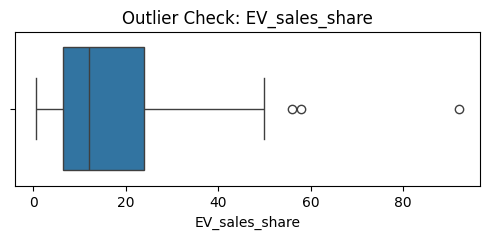

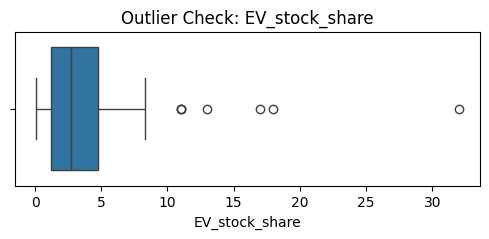

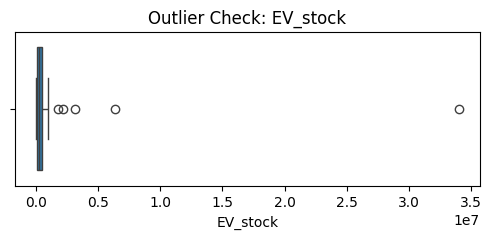

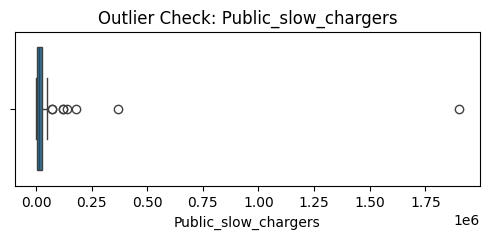

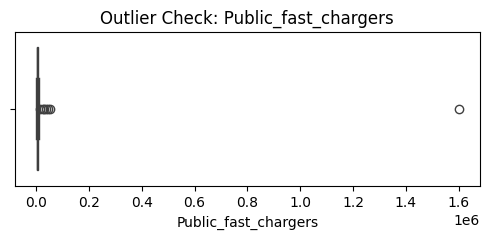

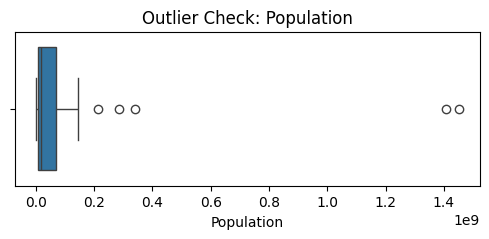

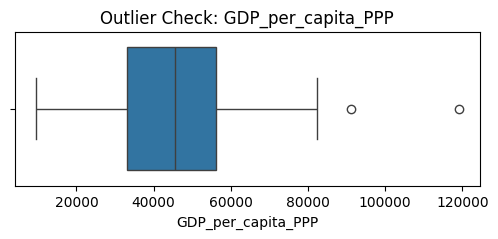

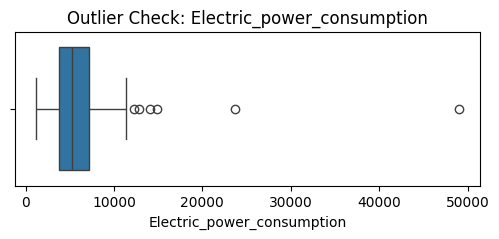

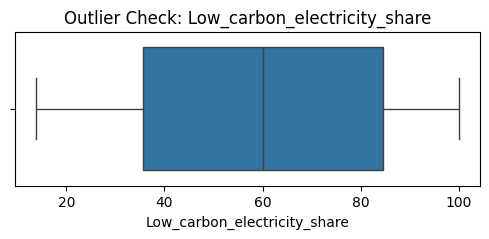

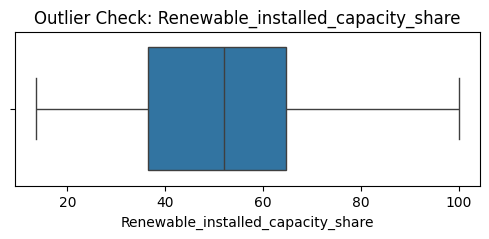

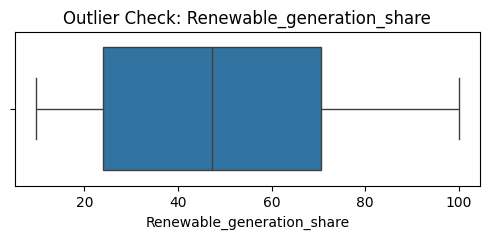

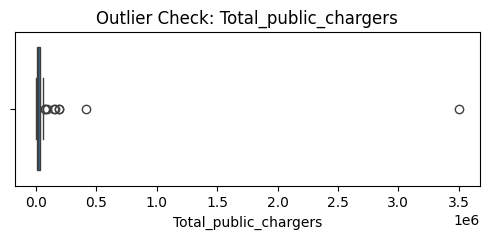

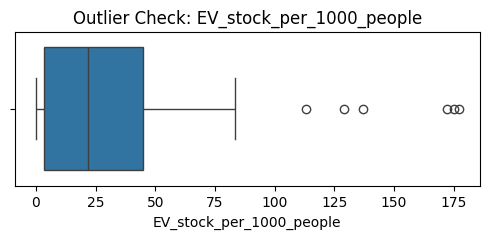

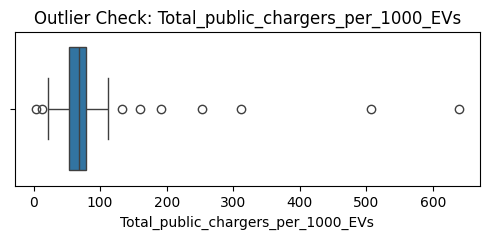

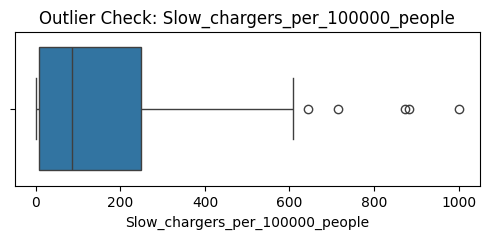

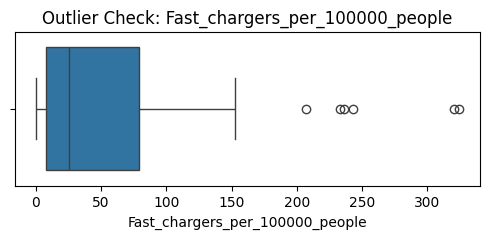

In [149]:
# The numeric variables have different scales, so each boxplot is shown separately.
for column in analysis_columns:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=merged_df[column])
    plt.title("Outlier Check: " + column)
    plt.show()

## Count Outliers Using the IQR Rule

The IQR method identifies values that are far below or above the middle spread of the data.

In [150]:
# Summarise possible outliers after the boxplots.
outlier_summary = []
country_outlier_counts = pd.Series(0, index=merged_df.index)

for column in analysis_columns:
    q1 = merged_df[column].quantile(0.25)
    q3 = merged_df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Mark values that sit outside the normal IQR range.
    outlier_mask = (merged_df[column] < lower_bound) | (merged_df[column] > upper_bound)
    outlier_count = outlier_mask.sum()
    country_outlier_counts = country_outlier_counts + outlier_mask.astype(int)

    outlier_summary.append([column, outlier_count, lower_bound, upper_bound])

outlier_summary_df = pd.DataFrame(outlier_summary, columns=["Variable", "Outlier_Count", "Lower_Bound", "Upper_Bound"])
outlier_summary_df = outlier_summary_df.sort_values(by="Outlier_Count", ascending=False)

print("Outlier count summary by variable:")
print(outlier_summary_df)

country_outlier_summary = merged_df[["Country"]].copy()
country_outlier_summary["Outlier_Count"] = country_outlier_counts
country_outlier_summary = country_outlier_summary.sort_values(by="Outlier_Count", ascending=False)

print("\nCountries appearing most often as outliers:")
print(country_outlier_summary.head(10))

print("\nNote: Outliers are not automatically removed here because high values may be genuine for large countries or EV-leading countries.")

Outlier count summary by variable:
                              Variable  Outlier_Count   Lower_Bound  \
13  Total_public_chargers_per_1000_EVs              9  1.377037e+01   
11               Total_public_chargers              9 -2.907500e+04   
3                 Public_slow_chargers              8 -2.725000e+04   
1                       EV_stock_share              7 -4.162500e+00   
4                 Public_fast_chargers              7 -3.925000e+03   
12            EV_stock_per_1000_people              6 -5.941225e+01   
15     Fast_chargers_per_100000_people              6 -9.907498e+01   
7           Electric_power_consumption              6 -1.313121e+03   
14     Slow_chargers_per_100000_people              5 -3.565491e+02   
5                           Population              5 -8.836106e+07   
2                             EV_stock              5 -4.485950e+05   
0                       EV_sales_share              3 -1.981250e+01   
6                   GDP_per_capita_PPP    

## Outlier Summary

The boxplots and IQR output are used to identify unusual values, not to remove them automatically.

Some outliers are expected in this project because countries differ greatly in population size, income level, EV market size, and charging infrastructure. Large countries may appear as outliers for raw totals such as EV stock or public chargers, while smaller EV-leading countries may stand out on per-capita indicators.

These values are kept at this stage because they are likely to represent real country differences rather than data errors. Their influence can be handled later during normalisation, especially by using transformations for highly skewed variables where needed.

## Save 2024 Cleaned and Imputed Dataset

The cleaned dataset is saved with only the fields needed for the final composite index. Helper fields such as source years, country keys, missing-count checks, and raw totals used only for calculations are not included in the saved cleaned dataset.

In [ ]:
# Keep only the final cleaned 2024 columns.
cleaned_columns = [
    "Country",
    "EV_sales_share",
    "EV_stock_share",
    "EV_stock_per_1000_people",
    "Total_public_chargers_per_1000_EVs",
    "Slow_chargers_per_100000_people",
    "Fast_chargers_per_100000_people",
    "GDP_per_capita_PPP",
    "Electric_power_consumption",
    "Low_carbon_electricity_share",
    "Renewable_installed_capacity_share",
    "Renewable_generation_share"
]

cleaned_df = merged_df[cleaned_columns]

# Keep the imputation flags in a separate file for transparency.
imputed_flag_columns = [column for column in merged_df.columns if column.endswith("_imputed")]
imputation_flags_df = merged_df[["Country"] + imputed_flag_columns]

# Save the 2024 cleaned data to CSV files.
cleaned_output_file = r"Cleaned_Datasets\EV_Index_Cleaned_Imputed_2024.csv"
flags_output_file = r"Cleaned_Datasets\EV_Index_Imputation_Flags_2024.csv"

cleaned_df.to_csv(cleaned_output_file, index=False)
imputation_flags_df.to_csv(flags_output_file, index=False)

print(f"2024 cleaned dataset for {len(cleaned_df)} countries saved to '{cleaned_output_file}'.")
print(f"2024 imputation flag data saved to '{flags_output_file}'.")

# Multivariate Analysis

The aim of this section is to understand how the 2024 EV readiness indicators relate to each other and whether the five sub-indices make sense statistically.

## Load Cleaned 2024 Dataset

In [344]:
df_mva = pd.read_csv(r"Cleaned_Datasets\EV_Index_Cleaned_Imputed_2024.csv")

print("MVA dataset shape:", df_mva.shape)
df_mva.head()

MVA dataset shape: (52, 12)


,Country,EV_sales_share,EV_stock_share,EV_stock_per_1000_people,Total_public_chargers_per_1000_EVs,Slow_chargers_per_100000_people,Fast_chargers_per_100000_people,GDP_per_capita_PPP,Electric_power_consumption,Low_carbon_electricity_share,Renewable_installed_capacity_share,Renewable_generation_share
0,Australia,13.0,1.9,11.107515,22.178894,10.295324,14.339916,60303.981712,9800.045682,35.076690,52.107585,38.10
1,Austria,24.0,5.3,29.969769,99.250351,228.808468,68.642540,63788.078678,7896.833966,86.224040,64.922277,87.90
2,Belgium,43.0,11.0,56.507466,111.326668,607.153790,21.924998,63347.785881,7098.808376,76.345215,56.031812,37.63
3,Brazil,6.4,0.7,1.009455,58.877679,5.660415,0.283021,19652.365499,3068.096123,89.449130,80.759324,88.21
4,Bulgaria,5.0,2.7,37.333843,68.196089,186.294297,68.307909,34221.529462,5360.503435,71.122720,43.170343,30.28


## Preparing the Data

The indicators are grouped into the five sub-indices used for the EV Transition Readiness Index.

In [345]:
# Define each sub-index and the indicators that belong to it.
indicator_groups = {
    # Sub-index 1: EV Adoption
    "EV Adoption": [
        "EV_sales_share",
        "EV_stock_share"
    ],

    # Sub-index 2: EV Penetration
    "EV Penetration": [
        "EV_stock_per_1000_people",
        "Total_public_chargers_per_1000_EVs"
    ],

    # Sub-index 3: Charging Infrastructure
    "Charging Infrastructure": [
        "Slow_chargers_per_100000_people",
        "Fast_chargers_per_100000_people"
    ],

    # Sub-index 4: National Readiness
    "National Readiness": [
        "GDP_per_capita_PPP",
        "Electric_power_consumption"
    ],

    # Sub-index 5: Clean Energy Readiness
    "Clean Energy Readiness": [
        "Low_carbon_electricity_share",
        "Renewable_installed_capacity_share",
        "Renewable_generation_share"
    ]
}

indicator_columns = []

for group_name in indicator_groups:
    indicator_columns = indicator_columns + indicator_groups[group_name]

expected_columns = ["Country"] + indicator_columns
missing_columns = [column for column in expected_columns if column not in df_mva.columns]

if len(missing_columns) > 0:
    print("Missing columns:")
    print(missing_columns)
    raise ValueError("One or more expected columns are missing from the cleaned 2024 dataset.")
else:
    print("All expected columns were found.")
    print("Number of indicators:", len(indicator_columns))

print()
print("Sub-index groups:")

for group_name, columns in indicator_groups.items():
    print(group_name, ":", columns)

All expected columns were found.
Number of indicators: 11

Sub-index groups:
EV Adoption : ['EV_sales_share', 'EV_stock_share']
EV Penetration : ['EV_stock_per_1000_people', 'Total_public_chargers_per_1000_EVs']
Charging Infrastructure : ['Slow_chargers_per_100000_people', 'Fast_chargers_per_100000_people']
National Readiness : ['GDP_per_capita_PPP', 'Electric_power_consumption']
Clean Energy Readiness : ['Low_carbon_electricity_share', 'Renewable_installed_capacity_share', 'Renewable_generation_share']


In [346]:
# Keep country names separate because the analysis below only uses numeric indicators.
countries = df_mva[["Country"]].copy()
indicator_df = df_mva[indicator_columns].copy()

# Make sure every indicator is treated as numeric before correlations and plots.
for column in indicator_columns:
    indicator_df[column] = pd.to_numeric(indicator_df[column], errors="coerce")

indicator_df.head()

,EV_sales_share,EV_stock_share,EV_stock_per_1000_people,Total_public_chargers_per_1000_EVs,Slow_chargers_per_100000_people,Fast_chargers_per_100000_people,GDP_per_capita_PPP,Electric_power_consumption,Low_carbon_electricity_share,Renewable_installed_capacity_share,Renewable_generation_share
0,13.0,1.9,11.107515,22.178894,10.295324,14.339916,60303.981712,9800.045682,35.076690,52.107585,38.10
1,24.0,5.3,29.969769,99.250351,228.808468,68.642540,63788.078678,7896.833966,86.224040,64.922277,87.90
2,43.0,11.0,56.507466,111.326668,607.153790,21.924998,63347.785881,7098.808376,76.345215,56.031812,37.63
3,6.4,0.7,1.009455,58.877679,5.660415,0.283021,19652.365499,3068.096123,89.449130,80.759324,88.21
4,5.0,2.7,37.333843,68.196089,186.294297,68.307909,34221.529462,5360.503435,71.122720,43.170343,30.28


## Basic Statistics

Descriptive statistics give a first view of the spread, minimum values, maximum values, and possible extreme values in the indicator set.

In [347]:
# Summary statistics for the 11 indicators.
indicator_df.describe()

,EV_sales_share,EV_stock_share,EV_stock_per_1000_people,Total_public_chargers_per_1000_EVs,Slow_chargers_per_100000_people,Fast_chargers_per_100000_people,GDP_per_capita_PPP,Electric_power_consumption,Low_carbon_electricity_share,Renewable_installed_capacity_share,Renewable_generation_share
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000
mean,18.082885,4.454846,36.892500,93.979959,199.705268,61.030031,45301.924202,6852.909242,58.858380,51.555717,48.574706
std,18.315548,5.643905,47.284773,111.179297,261.541044,82.347564,21919.643999,7165.231061,27.540433,20.175643,27.218958
min,0.610000,0.066000,0.079725,3.742468,0.296842,0.191042,9520.250645,1181.631268,13.805970,13.602562,9.690000
25%,6.475000,1.200000,3.230626,53.250534,6.901514,7.774358,33132.870619,3758.482638,35.720698,36.415532,24.072500
50%,12.000000,2.700000,21.715417,68.196089,85.038296,25.311989,45629.983450,5244.978822,59.992010,52.056688,47.225000
75%,24.000000,4.775000,44.992541,79.570646,249.201923,79.007250,56269.066919,7139.551418,84.525199,64.771369,70.490000
max,92.000000,32.000000,177.049390,638.591118,1000.362075,323.938622,119037.731175,48997.945698,100.000000,100.000000,99.980000


**Basic Statistics Summary**

- **Spread:** The indicators are measured in very different units. Some are percentages, some are per-capita rates, and some are larger national context measures.
- **Minimum values:** Low minimum values show that some countries are still at an early stage of EV adoption, charging infrastructure, or clean electricity development.
- **Maximum values:** Some maximum values are much higher than the rest of the sample. This matches the outlier checks completed earlier.
- **Meaning for the index:** These differences are acceptable at this stage, but they confirm why the indicators must later be normalised before the final composite index is calculated.

## Overall Indicator Correlation Matrix

The full correlation matrix shows how all 11 indicators relate to each other. This helps identify broad patterns across the whole index before checking each sub-index separately.

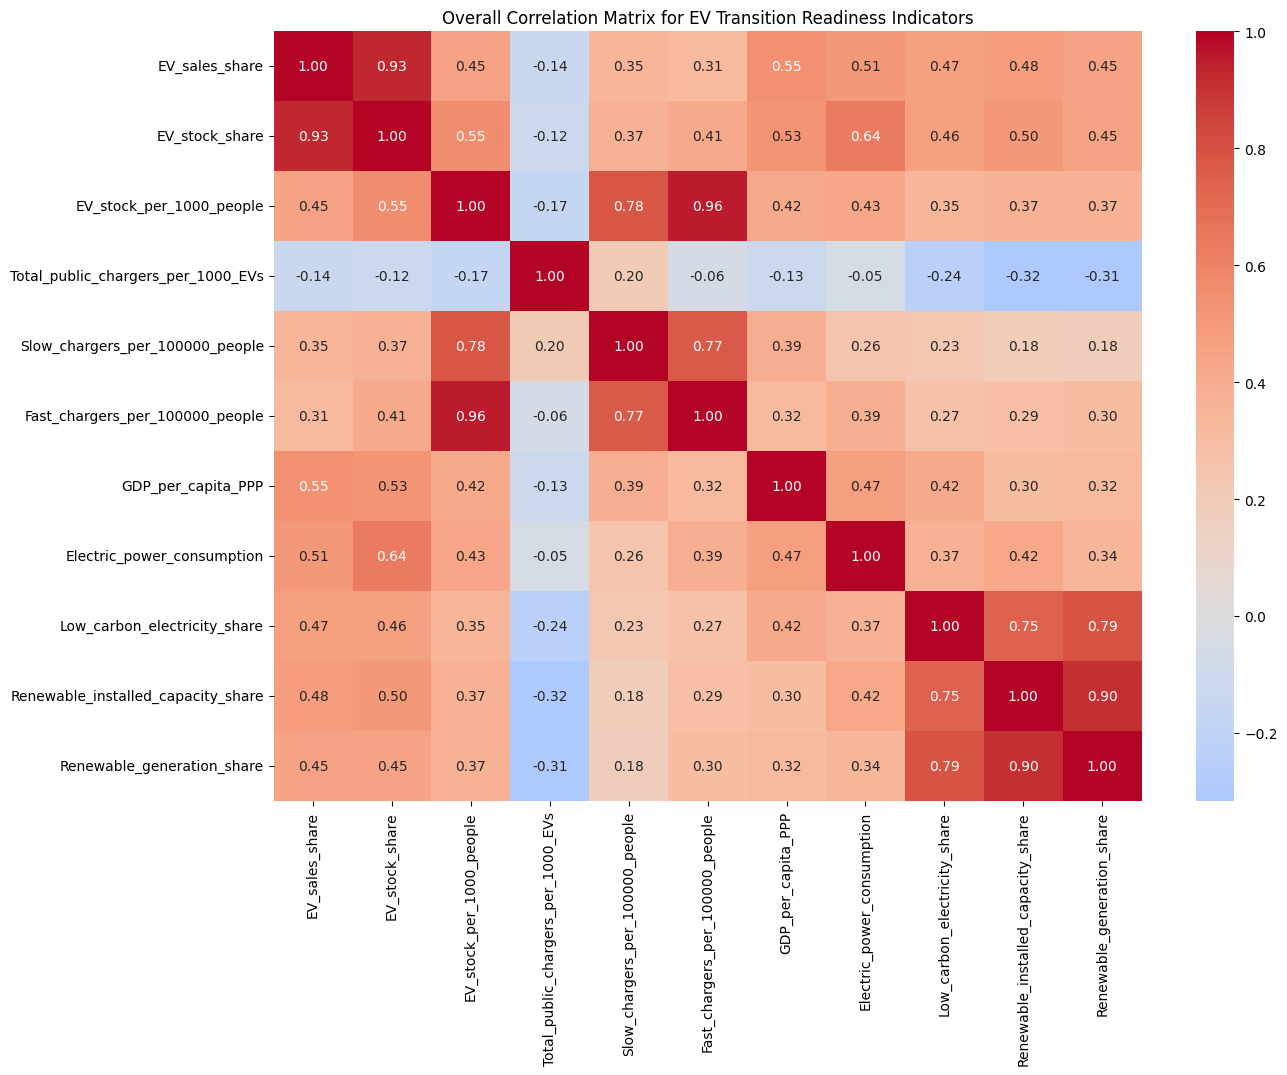

In [348]:
# Correlation matrix for all 11 indicators.
correlation_matrix = indicator_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Overall Correlation Matrix for EV Transition Readiness Indicators")
plt.show()

In [349]:
# Pull out very strong correlations so they are easier to discuss.
high_correlation_rows = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        indicator_1 = correlation_matrix.columns[i]
        indicator_2 = correlation_matrix.columns[j]
        correlation_value = correlation_matrix.iloc[i, j]

        if abs(correlation_value) >= 0.8:
            high_correlation_rows.append({
                "Indicator_1": indicator_1,
                "Indicator_2": indicator_2,
                "Correlation": round(correlation_value, 3)
            })

high_correlation_df = pd.DataFrame(high_correlation_rows)
high_correlation_df

,Indicator_1,Indicator_2,Correlation
0,EV_sales_share,EV_stock_share,0.933
1,EV_stock_per_1000_people,Fast_chargers_per_100000_people,0.956
2,Renewable_installed_capacity_share,Renewable_generation_share,0.903


**Overall Correlation Summary**

- EV stock per 1,000 people is very strongly positively correlated with fast chargers per 100,000 people, with r = 0.956. This makes sense because countries with more EVs on the road usually need stronger fast-charging infrastructure to support everyday use and longer journeys.
- EV sales share is very strongly positively correlated with EV stock share, with r = 0.933. This is expected because strong current EV sales gradually build up the total EV fleet over time.
- Renewable installed capacity share is very strongly positively correlated with renewable generation share, with r = 0.903. This is logical because countries with more renewable capacity available are usually able to generate more electricity from renewable sources.
- Slow chargers per 100,000 people is strongly positively correlated with fast chargers per 100,000 people, with r = 0.769. This suggests that countries investing in public charging tend to develop both everyday charging and faster long-distance charging.
- GDP per capita PPP is moderately positively correlated with electric power consumption, with r = 0.473. Wealthier countries often have stronger energy use and infrastructure, but the relationship is not perfect because electricity consumption also depends on industry, climate, and energy policy.
- EV stock per 1,000 people is weakly negatively correlated with public chargers per 1,000 EVs, with r = -0.167. This is interesting because mature EV markets may have many EVs but fewer public chargers per EV if home, workplace, or private charging is common.
- The strongest possible overlap is between renewable installed capacity and renewable generation. This does not mean either indicator must be removed now, but it should be considered later during PCA and weighting.

## Sub-Index Correlation Checks

Each sub-index is checked separately so it is clear whether the indicators inside that dimension are statistically connected. This makes the structure easier to explain than relying only on the full 11-indicator matrix.

In [350]:
def describe_correlation(value):
    value = abs(value)

    if value >= 0.8:
        return "Very strong"
    elif value >= 0.6:
        return "Strong"
    elif value >= 0.4:
        return "Moderate"
    else:
        return "Weak or no relationship"

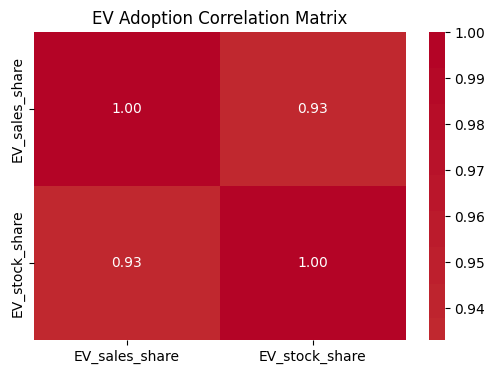

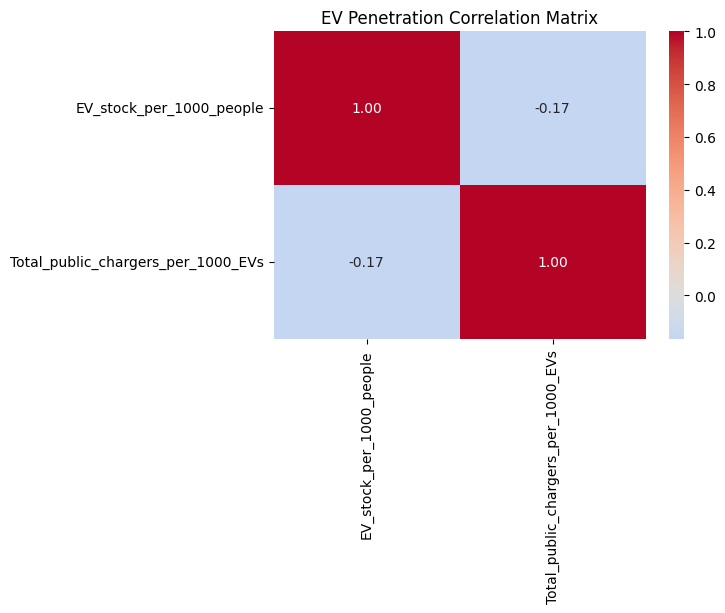

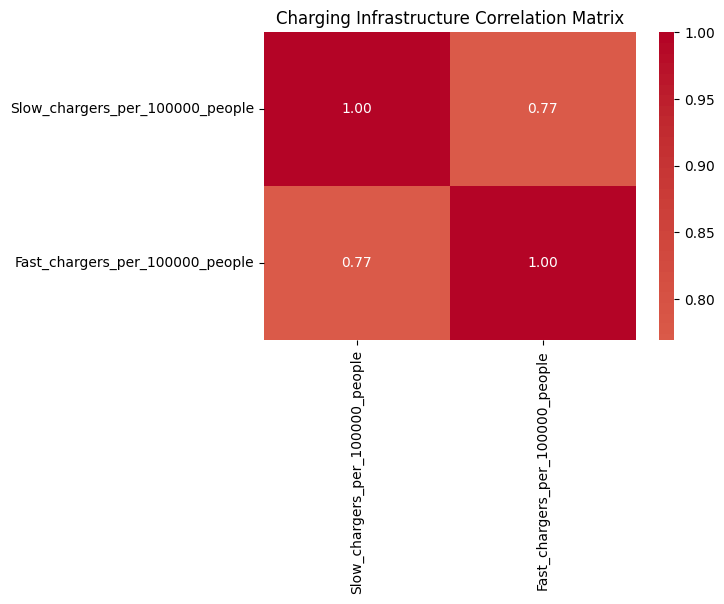

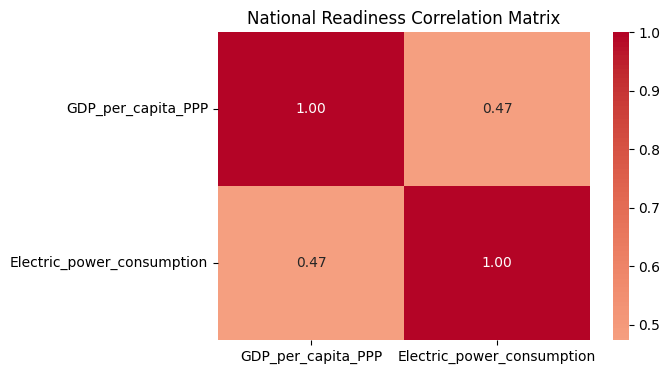

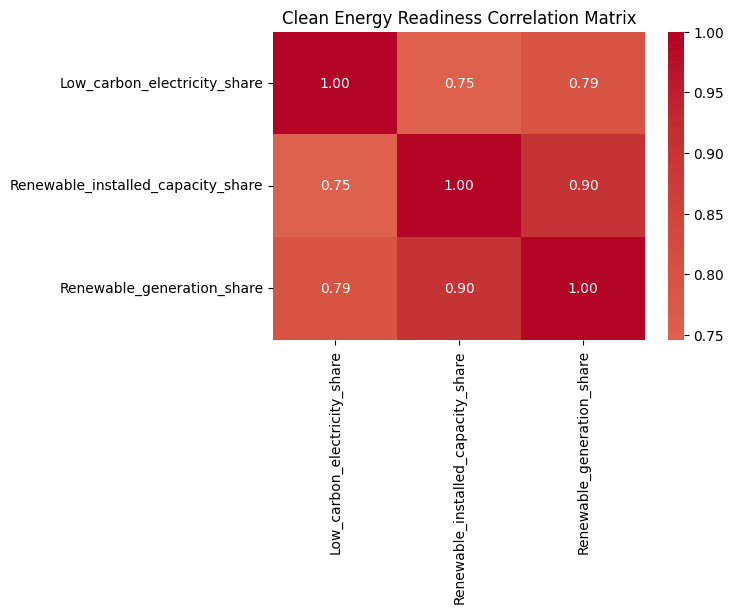

,Sub_Index,Indicator_1,Indicator_2,Correlation,Relationship
0,EV Adoption,EV_sales_share,EV_stock_share,0.933,Very strong
1,EV Penetration,EV_stock_per_1000_people,Total_public_chargers_per_1000_EVs,-0.167,Weak or no relationship
2,Charging Infrastructure,Slow_chargers_per_100000_people,Fast_chargers_per_100000_people,0.769,Strong
3,National Readiness,GDP_per_capita_PPP,Electric_power_consumption,0.473,Moderate
4,Clean Energy Readiness,Low_carbon_electricity_share,Renewable_installed_capacity_share,0.746,Strong
5,Clean Energy Readiness,Low_carbon_electricity_share,Renewable_generation_share,0.790,Strong
6,Clean Energy Readiness,Renewable_installed_capacity_share,Renewable_generation_share,0.903,Very strong


In [351]:
# Create a small correlation matrix for each sub-index.
sub_index_correlation_rows = []

for group_name, columns in indicator_groups.items():
    group_corr = indicator_df[columns].corr()

    plt.figure(figsize=(6, 4))
    sns.heatmap(group_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title(group_name + " Correlation Matrix")
    plt.show()

    # Store the pairwise values in a table for a clear written discussion.
    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            indicator_1 = columns[i]
            indicator_2 = columns[j]
            correlation_value = group_corr.loc[indicator_1, indicator_2]

            sub_index_correlation_rows.append({
                "Sub_Index": group_name,
                "Indicator_1": indicator_1,
                "Indicator_2": indicator_2,
                "Correlation": round(correlation_value, 3),
                "Relationship": describe_correlation(correlation_value)
            })

sub_index_correlation_df = pd.DataFrame(sub_index_correlation_rows)
sub_index_correlation_df

**Sub-Index Correlation Summary**

**Sub-Index 1: EV Adoption**

EV sales share is very strongly positively correlated with EV stock share, with r = 0.933. This is a good sign because new EV sales are the flow into the market, while EV stock share shows how much the total car fleet has already changed.

**Sub-Index 2: EV Penetration**

EV stock per 1,000 people is weakly negatively correlated with public chargers per 1,000 EVs, with r = -0.167. This is not necessarily a problem. It may show that countries with many EVs do not always need the highest number of public chargers per EV, especially if private charging is common.

**Sub-Index 3: Charging Infrastructure**

Slow chargers per 100,000 people is strongly positively correlated with fast chargers per 100,000 people, with r = 0.769. This suggests that charging infrastructure develops as a network, rather than as only one charger type.

**Sub-Index 4: National Readiness**

GDP per capita PPP is moderately positively correlated with electric power consumption, with r = 0.473. This is useful because the two indicators are connected but still different enough to measure separate parts of readiness.

**Sub-Index 5: Clean Energy Readiness**

Low-carbon electricity share is strongly positively correlated with renewable installed capacity share, with r = 0.746, and strongly positively correlated with renewable generation share, with r = 0.790. Renewable installed capacity share is very strongly positively correlated with renewable generation share, with r = 0.903. This supports the clean energy sub-index, but the very high capacity-generation relationship may need careful interpretation later.

## Scatterplots by Sub-Index

Scatterplots show the shape of each relationship. They help check whether the correlation values are being driven by a real trend or by a few unusual countries.

In [352]:
def plot_relationship(x_column, y_column, title):
    x = indicator_df[x_column]
    y = indicator_df[y_column]

    plt.figure(figsize=(7, 5))
    plt.title(title)
    plt.xlabel(x_column)
    plt.ylabel(y_column)

    # Each point represents one country in the cleaned 2024 dataset.
    plt.scatter(x, y)

    # A simple trend line makes the direction of the relationship easier to see.
    plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)))

    plt.grid(True)
    plt.show()

### Sub-Index 1: EV Adoption

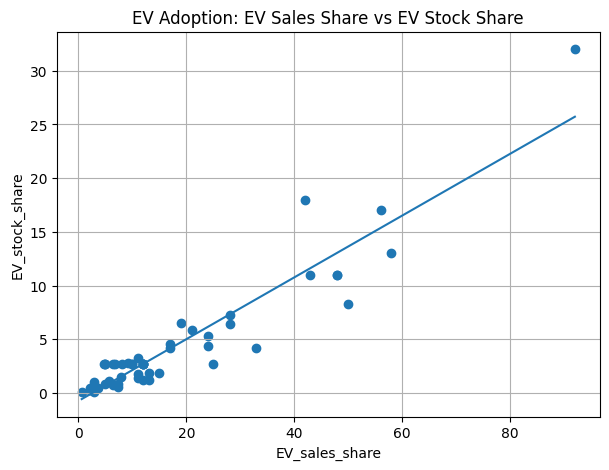

In [353]:
plot_relationship(
    "EV_sales_share",
    "EV_stock_share",
    "EV Adoption: EV Sales Share vs EV Stock Share"
)

- **Pattern:** The trend is clearly positive.
- **Correlation:** EV sales share is very strongly positively correlated with EV stock share, with r = 0.933.
- **Interpretation:** This relationship makes sense because high sales today are how countries build a larger EV fleet over time.
- **Index decision:** This supports keeping both indicators in the EV Adoption sub-index, although their strong relationship should be remembered during weighting.